In [1]:
"""
TO BE ADDED:

- Feature importance

"""


# Data wrangling libraries
import pandas as pd
import numpy as np
import time

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing libraries
from sklearn import preprocessing
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, RepeatedKFold, cross_val_predict, GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.decomposition import PCA

# Regression libraries
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LogisticRegression
import lightgbm as lgb
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor


# Metric libraries
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



pd.set_option('display.max_columns', None) # display all columns
pd.set_option('display.expand_frame_repr', False) # print all columns and in the same line
pd.set_option('display.max_colwidth', None) # display the full content of each cell
pd.set_option('display.float_format', lambda x: '%.3f' %x) # floats to be displayed with 3 decimal places

In [2]:
df = pd.read_csv("data/data_cleaned.csv")
#df = df.drop(columns=['postcode'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38986 entries, 0 to 38985
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   bedroomcount               38986 non-null  float64
 1   habitablesurface           38986 non-null  int64  
 2   haslift                    38986 non-null  int64  
 3   hasgarden                  38986 non-null  int64  
 4   hasswimmingpool            38986 non-null  int64  
 5   hasterrace                 38986 non-null  int64  
 6   price                      38986 non-null  float64
 7   hasparking                 38986 non-null  int64  
 8   epcscore_encoded           38986 non-null  float64
 9   buildingcondition_encoded  38986 non-null  float64
 10  region_Brussels            38986 non-null  float64
 11  region_Flanders            38986 non-null  float64
 12  region_Wallonia            38986 non-null  float64
 13  type_encoded               38986 non-null  int

In [3]:
# Set the datasets for analysis and the target variable
df_all = df
df_hs = df[df['type_encoded'] == 1]  # Houses
df_apt = df[df['type_encoded'] == 0]  # Apartments

target = 'price'

In [4]:
numVar = [target, 'bedroomcount', 'habitablesurface']
numVar

['price', 'bedroomcount', 'habitablesurface']

In [5]:
def makeBoxplot(var):

    plt.figure(figsize=(5, 2))
    plt.boxplot(df[var], vert=False, patch_artist=True, boxprops=dict(alpha=0.8),
                medianprops=dict(color='white'))

    plt.title(f'Boxplot of {var.capitalize()}', fontsize=14, fontweight='bold')
    plt.ylabel("")
    plt.xlabel("")
    plt.yticks([])
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


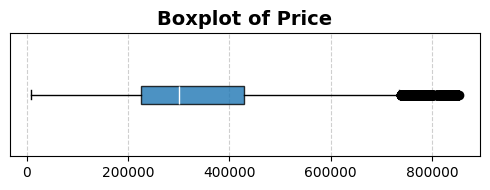

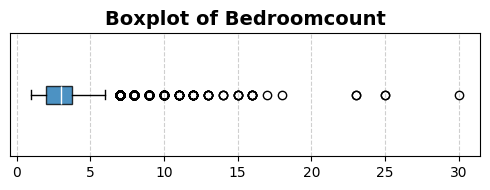

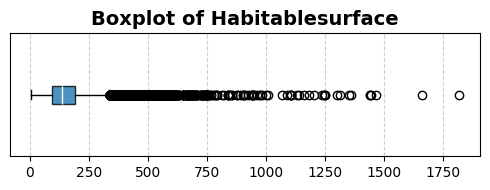

In [6]:
for var in numVar:
    makeBoxplot(var)

In [7]:
def splitDF(df, target):
    # Select target
    y = df[target]
    # Select predictors
    X = df.drop([target], axis=1)
    return X, y


In [8]:
def regResults(df, obs, name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # Return a dictionary with the metrics
    return {
        "Dataset": df,
        "Observations": obs,
        "Model": name,
        "R² Score": r2,
        "MAE": mae,
        "RMSE": rmse
    }


In [9]:
def plotPredictions(df, name, y_true, y_pred):
    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], '--r')
    plt.title(f"{name} - {df} — Predicted vs Actual")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# REGRESSION MODELS

In [10]:
cv = KFold(n_splits=10, shuffle=True, random_state=123)

results = []

models = { 
    # with default parameters
    "Linear": LinearRegression(),
    "LightGBM": lgb.LGBMRegressor(verbosity=-1),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "Decision Tree": DecisionTreeRegressor(random_state=123),
    "Random Forest": RandomForestRegressor(random_state=123),
    "Gradient Boosting": GradientBoostingRegressor(random_state=123),
    "XGBoost": XGBRegressor(random_state=123)
}

def runModels(df_all, obs, models, cv):

    X, y = splitDF(df_all, target)

    for model_name, model in models.items():

        if model_name in ["Linear", "Ridge", "Lasso", "ElasticNet"]:
            pipeline = make_pipeline(StandardScaler(), model)
        else:
            pipeline = make_pipeline(model)

        y_pred = cross_val_predict(pipeline, X, y, cv=cv)
        results.append(regResults("All properties", obs, model_name, y, y_pred))
            
    results_df = pd.DataFrame(results)
    return results_df


In [11]:
results_df = runModels(df_all, "All features", models, cv)
print("\nSummary of Regression Results:")
print(results_df.sort_values(by=["Dataset", "RMSE"]))


Summary of Regression Results:
          Dataset  Observations              Model  R² Score       MAE       RMSE
8  All properties  All features            XGBoost     0.742 59731.056  83903.296
1  All properties  All features           LightGBM     0.740 60489.623  84228.316
6  All properties  All features      Random Forest     0.724 61488.583  86678.524
7  All properties  All features  Gradient Boosting     0.683 68279.731  92945.497
2  All properties  All features              Ridge     0.513 85247.001 115229.761
3  All properties  All features              Lasso     0.513 85246.936 115229.768
0  All properties  All features             Linear     0.513 85246.954 115229.768
4  All properties  All features         ElasticNet     0.474 90185.734 119714.602
5  All properties  All features      Decision Tree     0.462 83448.041 121046.957


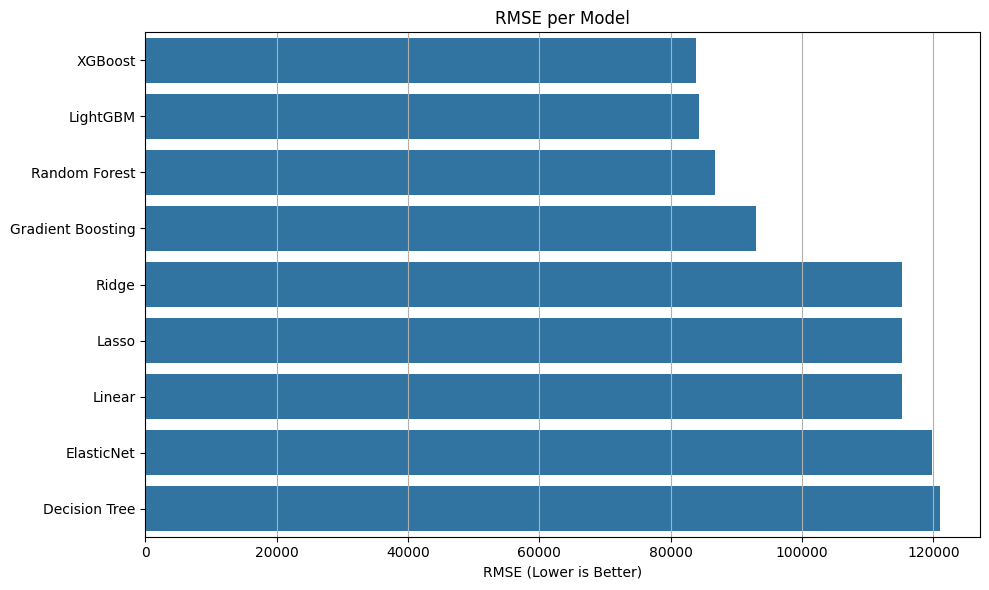

In [12]:
results_df_sorted = results_df.sort_values("RMSE", ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_df_sorted,
    y="Model", x="RMSE",
    #palette="viridis"
)

plt.title("RMSE per Model")
plt.xlabel("RMSE (Lower is Better)")
plt.ylabel("")
plt.grid(True, axis='x')
plt.tight_layout()
plt.show();

After the first run with several models, we find 3 models that perform best:
LightGBM, XGBoost and Random Forest.

We will develop these 3 models.

# TUNING XGBOOST

In [13]:
def XGBoost_withRandomS(df_all, obs, target):

    # Split data into train and test as needed to run cross_val_predict
    X, y = splitDF(df_all, target)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

    # Set hyperparameter grid
    xgb_params = {
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "n_estimators": [100, 500, 1000, 1500, 2000],
        "max_depth": [3, 6, 10, 15],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0]
    }

    # Initialize model
    xgb_model = XGBRegressor(objective='reg:squarederror', eval_metric='rmse', random_state=123)

    # Tune hyperparameters
    xgb_search = RandomizedSearchCV(
        xgb_model, xgb_params,
        n_iter=10, cv=2,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1, verbose=1,
        random_state=123
    )

    xgb_search.fit(X_train, y_train)

    # Extract and print best parameters
    best_xgb_params = xgb_search.best_params_
    print(f"\nBest Hyperparameters for XGBoost:")
    for param, value in best_xgb_params.items():
        print(f"\t{param}: {value}")

    # Predict on test set using the best model
    best_xgb = xgb_search.best_estimator_
    y_pred_xgb = best_xgb.predict(X_test)


    # Predict on test set using the best model
    best_xgb = xgb_search.best_estimator_
    y_pred_xgb = best_xgb.predict(X_test)

    newResult = regResults("All properties", obs, "XGBoost", y_test, y_pred_xgb)
    return newResult



In [14]:
start = time.time()
newResult = XGBoost_withRandomS(df_all, "RandomizedSearchCV", target)
print(newResult)
end = time.time()
code_run = (end - start) / 60
print(f"\nIt took {code_run:.2f} minutes to run the code.")

print("\nSummary of Regression Results:")
results_df = pd.concat([results_df, pd.DataFrame([newResult])], ignore_index=True)
print(results_df.sort_values(by=["Dataset", "RMSE"]))


Fitting 2 folds for each of 10 candidates, totalling 20 fits

Best Hyperparameters for XGBoost:
	subsample: 0.6
	n_estimators: 1000
	max_depth: 6
	learning_rate: 0.01
	colsample_bytree: 0.8
{'Dataset': 'All properties', 'Observations': 'RandomizedSearchCV', 'Model': 'XGBoost', 'R² Score': 0.7465955170902587, 'MAE': 59518.441602113526, 'RMSE': np.float64(83456.18499369116)}

It took 2.67 minutes to run the code.

Summary of Regression Results:
          Dataset        Observations              Model  R² Score       MAE       RMSE
9  All properties  RandomizedSearchCV            XGBoost     0.747 59518.442  83456.185
8  All properties        All features            XGBoost     0.742 59731.056  83903.296
1  All properties        All features           LightGBM     0.740 60489.623  84228.316
6  All properties        All features      Random Forest     0.724 61488.583  86678.524
7  All properties        All features  Gradient Boosting     0.683 68279.731  92945.497
2  All properties        

In [15]:
def XGBoost_withRSandEarlyStop(df_all, obs, models, cv):

    # Split data into train and test as needed to run cross_val_predict
    X, y = splitDF(df_all, target)
    # Split data into train and test as needed to run cross_val_predict
    X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=123)
    # Further split training data into training and validation sets for early stopping
    X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=123)


    # Set hyperparameter grid
    xgb_params = {
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "n_estimators": [100, 500, 1000, 1500, 2000],
        "max_depth": [3, 6, 10, 15],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0]
    }

    # Initialize model
    xgb_model = XGBRegressor(objective='reg:squarederror', eval_metric='rmse', early_stopping_rounds=50, random_state=123)

    # Tune hyperparameters
    xgb_search = RandomizedSearchCV(
        xgb_model, xgb_params,
        n_iter=10, cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1, verbose=1,
        random_state=123
    )

    xgb_search.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    # Extract and print best parameters
    best_xgb_params = xgb_search.best_params_
    print(f"\nBest Hyperparameters for XGBoost:")
    for param, value in best_xgb_params.items():
        print(f"\t{param}: {value}")

    # Predict on test set using the best model
    best_xgb = xgb_search.best_estimator_
    y_pred_xgb = best_xgb.predict(X_test)


    # Predict on test set using the best model
    best_xgb = xgb_search.best_estimator_
    y_pred_xgb = best_xgb.predict(X_test)

    newResult = regResults("All properties", obs, "XGBoost", y_test, y_pred_xgb)
    return newResult


In [16]:
start = time.time()
newResult = XGBoost_withRandomS(df_all, "RsearchCV + EarlyStop", target)
end = time.time()
code_run = (end - start) / 60
print(f"\nIt took {code_run:.2f} minutes to run the code.")

print("\nSummary of Regression Results:")
results_df = pd.concat([results_df, pd.DataFrame([newResult])], ignore_index=True)
print(results_df.sort_values(by=["Dataset", "RMSE"]))


Fitting 2 folds for each of 10 candidates, totalling 20 fits

Best Hyperparameters for XGBoost:
	subsample: 0.6
	n_estimators: 1000
	max_depth: 6
	learning_rate: 0.01
	colsample_bytree: 0.8

It took 2.13 minutes to run the code.

Summary of Regression Results:
           Dataset           Observations              Model  R² Score       MAE       RMSE
9   All properties     RandomizedSearchCV            XGBoost     0.747 59518.442  83456.185
10  All properties  RsearchCV + EarlyStop            XGBoost     0.747 59518.442  83456.185
8   All properties           All features            XGBoost     0.742 59731.056  83903.296
1   All properties           All features           LightGBM     0.740 60489.623  84228.316
6   All properties           All features      Random Forest     0.724 61488.583  86678.524
7   All properties           All features  Gradient Boosting     0.683 68279.731  92945.497
2   All properties           All features              Ridge     0.513 85247.001 115229.761
3  

In [ ]:
# Set the datasets for analysis
df_all = df_cleaned
df_hs = df_cleaned[df_cleaned['type_encoded'] == 1]  # Houses
df_apt = df_cleaned[df_cleaned['type_encoded'] == 0]  # Apartments

datasets = {
    "All Properties": df_all,
    "Only Houses": df_hs,
    "Only Apartments": df_apt
}

results_df = runModels(datasets, "No outliers", models, cv)
print("\nSummary of Regression Results:")
print(results_df.sort_values(by=["Dataset", "RMSE"]))



In [ ]:
# PCA
# n_components=2	Keep only the top 2 components
# n_components=0.95	Keep enough components to explain 95% of the variance
# n_components='mle'	Let PCA choose the optimal number using MLE (only for full SVD)
# Omitted	Keep all components (just rotates them)

# Dictionary to hold PCA-transformed datasets
datasets_pca = {}

for name, df in datasets.items():
    
    X, y = splitDF(df, target)

    # Standardize predictors
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Apply PCA
    pca = PCA(n_components=0.95) # keep 95% variance
    X_pca = pca.fit_transform(X_scaled)

    # Create a DataFrame with principal components
    df_pca = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(X_pca.shape[1])])
    df_pca[target] = y.values  # add target column back

    # Save transformed dataset
    datasets_pca[name] = df_pca

# Run models with PCA
results_df = runModels(datasets_pca, "PCA", models, cv)

print("\nSummary of Regression Results:")
print(results_df.sort_values(by=["Dataset", "RMSE"]))

In [ ]:
r = results_df.sort_values(by=["Dataset", "RMSE"])
r.to_csv('Regression_scores.csv', index=False)